Follows from [fast_phoenix_single](fast_phoenix_single.ipynb) to load the full phoenix dataset and train on the stellar parameters in addition to wl

In [1]:
from collections import defaultdict
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from tqdm.auto import tqdm

from astropy import units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord

from astropy import visualization as viz
viz.quantity_support()

from jwst import datamodels

In [2]:
phoenix_path = Path('../phoenix/fullgrid')

allspec = list(phoenix_path.glob('*.fits'))
wavepaths = [path for path in allspec if 'WAVE' in path.name]
assert len(wavepaths) == 1

allspec = [path for path in allspec if 'WAVE' not in path.name]
len(allspec)

7559

In [3]:
with fits.open(wavepaths[0]) as f:
    wavehdu = f[0]
    ph_wave = wavehdu.data << u.Unit(wavehdu.header['UNIT'])

# Determine how to resample models to approximately span the data range

Load some example spectra to do this

In [4]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

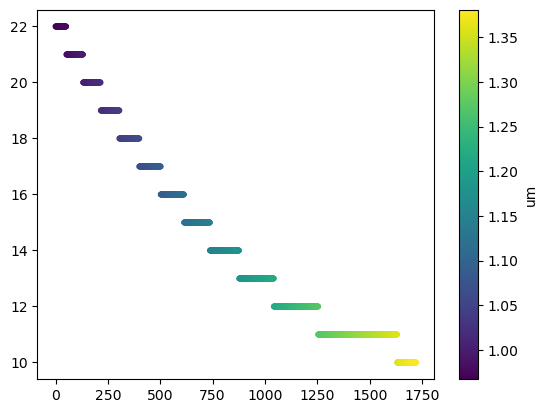

In [5]:
y, x = np.indices(slit.data.shape)
sky, spec = swcs.pixel_to_world(x, y)
densespec = np.linspace(np.nanmin(spec), np.nanmax(spec), x.shape[-1]*3)
source_sky = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')

xdense, ydense = swcs.world_to_pixel(source_sky, densespec)

xdr = np.round(xdense - .5)
ydr = np.round(ydense - .5)
pixelsets = set([(x,y) for x,y in zip(xdr, ydr) if np.isfinite(x) and np.isfinite(y)])
upix = np.array(list(pixelsets))
upix = upix[np.argsort(upix[:, 0])]

uwl = swcs.pixel_to_world(upix[:, 0], upix[:, 1])[-1]

plt.scatter(upix[:, 0], upix[:, 1], c=uwl.value, s=10)
plt.colorbar().set_label(uwl.unit)

(<SpectralCoord 2.40316794 Angstrom>, <SpectralCoord 2.39364441 Angstrom>)

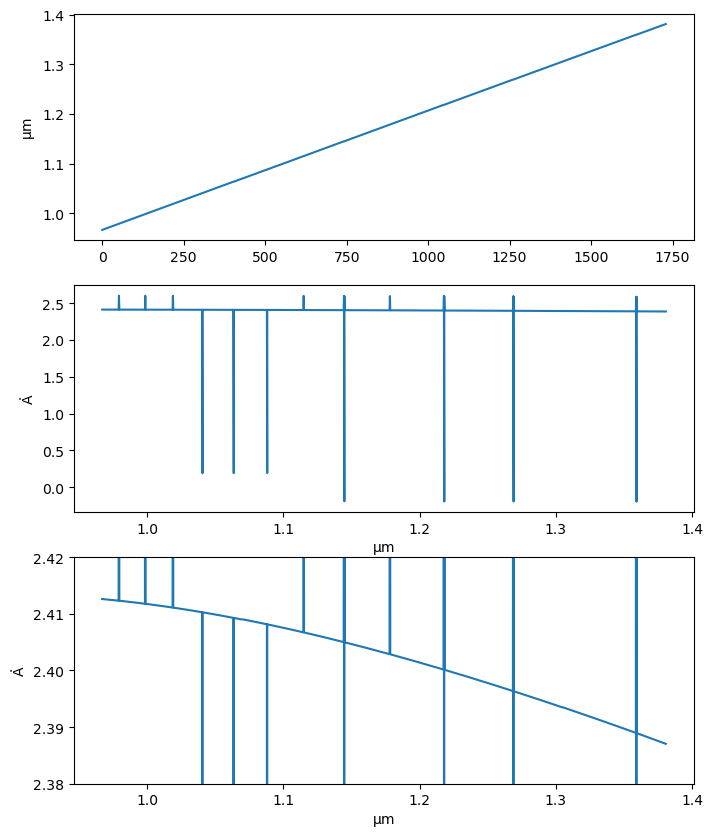

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))
ax1.plot(uwl)
ax2.plot(uwl[:-1], np.diff(uwl).to(u.angstrom))
ax3.plot(uwl[:-1], np.diff(uwl).to(u.angstrom))
ax3.set_ylim(2.38, 2.42)
np.median(np.diff(uwl).to(u.angstrom)), np.mean(np.diff(uwl).to(u.angstrom))

This suggests that 1 angstrom resolution is sufficient for the model spectrum.  But lets try to do a bit better than that.

In [7]:
class PhoenixResampler:
    def __init__(self, target_spacing, ph_wave, densespec):
        self.target_spacing = target_spacing
        msk = (densespec[0] < ph_wave) & (ph_wave < densespec[-1])
        self.resample_factor = int(round(target_spacing/np.max(np.diff(ph_wave[msk].to(u.angstrom)))))
        self.resample_msk = (densespec[0] < ph_wave) & (ph_wave < (densespec[-1]+target_spacing))
        self.cutoff_len = int(np.sum(self.resample_msk)/self.resample_factor)*self.resample_factor
        self.wave = self.subsample_data(ph_wave)

    def subsample_data(self, data):
        diced = data[self.resample_msk][:self.cutoff_len].reshape(-1, self.resample_factor)
        res = diced.mean(axis=1) 
        if hasattr(data, 'unit'):
            res = res << data.unit
        return res

phoenix_resampler = PhoenixResampler(0.5*u.angstrom, ph_wave, densespec)
phoenix_resampler.wave.shape

(8945,)

Make sure the full set of resampled spectra wont overwhelm the GPU

In [8]:
len(allspec) * phoenix_resampler.wave.size * 4 * 1024**-2 #MB, float32

257.9317283630371

257 MB, not large at all

# Load data into jax / GPU

In [9]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
rkey = jax.random.PRNGKey(42)
jax.devices()

[CudaDevice(id=0)]

In [10]:
resampled_models = []
metas = defaultdict(list)
for path in tqdm(allspec):
    with fits.open(path) as f:
        resampled_models.append(phoenix_resampler.subsample_data(f[0].data))
        for key in ['PHXTEFF', 'PHXLOGG', 'PHXM_H', 'PHXALPHA']:
            metas[key].append(f[0].header[key])

models = jnp.array(resampled_models, dtype=jnp.float32)
metas = dict(metas)

assert len(next(iter(metas.values()))) == models.shape[0]
models.shape

  0%|          | 0/7559 [00:00<?, ?it/s]

(7559, 8945)

In [11]:
for key, val in metas.items():
    print(key, np.unique(val))

PHXTEFF [ 2300.  2400.  2500.  2600.  2700.  2800.  2900.  3000.  3100.  3200.
  3300.  3400.  3500.  3600.  3700.  3800.  3900.  4000.  4100.  4200.
  4300.  4400.  4500.  4600.  4700.  4800.  4900.  5000.  5100.  5200.
  5300.  5400.  5500.  5600.  5700.  5800.  5900.  6000.  6100.  6200.
  6300.  6400.  6500.  6600.  6700.  6800.  6900.  7000.  7200.  7400.
  7600.  7800.  8000.  8200.  8400.  8600.  8800.  9000.  9200.  9400.
  9600.  9800. 10000. 10200. 10400. 10600. 10800. 11000. 11200. 11400.
 11600. 11800. 12000.]
PHXLOGG [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
PHXM_H [-4.  -3.  -2.  -1.5 -1.  -0.5  0.   0.5  1. ]
PHXALPHA [0.]


Ignore alpha since we're not letting in vary here yet

In [12]:
stellar_parameter_names= ['PHXTEFF', 'PHXLOGG', 'PHXM_H']
stellar_parameter_arrs = jnp.array([metas[k] for k in stellar_parameter_names])
stellar_parameter_arrs.shape

(3, 7559)

## Normalize and collect the data together

### Coordinates

In [13]:
class Normalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.scale = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.scale * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.scale + self.min

In [14]:
wlnorm = Normalizer(phoenix_resampler.wave.value)
model_wave_norm = wlnorm.normalize(phoenix_resampler.wave.value)
model_wave_norm.shape

(8945,)

In [15]:
stellar_parameter_normalizers = []
xs_split = []

xs_split.append(jnp.broadcast_to(model_wave_norm[None, :], (stellar_parameter_arrs[0].size, model_wave_norm.size)))

for sp in stellar_parameter_arrs:
    stellar_parameter_normalizers.append(Normalizer(sp))
    single_axis = stellar_parameter_normalizers[-1].normalize(sp)
    bcast = jnp.broadcast_to(single_axis[:, None], (single_axis.size, model_wave_norm.size))
    xs_split.append(bcast)


xs_split = jnp.stack(xs_split, axis=-1)
xs_split.shape, (xs_split.min(), xs_split.max())

((7559, 8945, 4), (Array(-1., dtype=float32), Array(1., dtype=float32)))

### Fluxes

In [16]:
models.size*models.dtype.itemsize * 1024**-2 # MB

257.9317283630371

We normalize the model fluxes to have each spectrum be on [0,1] - this makes recovery of the exact flux more challenging, but we dont care because our observed data is all normalized as observed flux anyway.  Then we also do a linear detrend on them. Note the detrending is hard to reverse so probably wont work for a real solution but it'll at least help speed up training.

In [17]:
model_scales = models.max(axis=-1)
models_normed = models / model_scales[:, None]

models_normed.min(), models_normed.max(), models_normed.shape

(Array(0.03008708, dtype=float32),
 Array(1.0000001, dtype=float32),
 (7559, 8945))

Now do a linear detrend on each

In [18]:
def linear_detrend1(x, y):
    design = X = jnp.vstack([x, jnp.ones(len(x))]).T
    p = jnp.linalg.lstsq(design, y, rcond=None)[0]
    return y - design @ p, p

models_detrended, model_params = jax.vmap(linear_detrend1, in_axes=(None, 0))(model_wave_norm, models_normed)

In [19]:
ys_split = models_detrended
ys_split.shape

(7559, 8945)

In [20]:
ys = ys_split.ravel()
xs = xs_split.reshape(-1, xs_split.shape[-1])
xs.shape, ys.shape

((67615255, 4), (67615255,))

# Define INR architecture

In [21]:
def inv_softplus(s):
    return jnp.log(jnp.exp(s) - 1)

class FDHOLayer(eqx.Module):
    lin: eqx.nn.Linear
    freq_params: jnp.ndarray # (ω', ωn')
    nonfreq_params: jnp.ndarray # (ξ, φ)

    def __init__(self, nin, nout, 
                 w0, wn0, xi0, phi0,
                 firstlayer,
                 rkey=None,trainable0s=True):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        if phi0 is None:
            # from the paper - physical lag of an oscillator with the other given parameters
            phi0 = -jnp.arctan2(2*xi0*w0*wn0, (wn0**2 - w0**2))

        wp0 = inv_softplus(w0)
        wnp0 = inv_softplus(wn0)
        self.freq_params = jnp.array([wp0, wnp0], dtype=jnp.float32)
        
        self.nonfreq_params = jnp.array([xi0, phi0], dtype=jnp.float32)

        rk1, = jax.random.split(rkey, 1)
        self.lin = self.init_lin(nin,nout, firstlayer, wn0, rk1)
        self.lin = eqx.nn.Linear(nin, nout, key=rk1)

    def init_lin(self, nin, nout, firstlayer, wn0, rkey):
        rk1, rk2 = jax.random.split(rkey, 2)

        init_lin = eqx.nn.Linear(nin, nout, key=rk1)

        if firstlayer:
            layerscale = jnp.sqrt(6/nout)
        else:
            layerscale = jnp.sqrt(jnp.sqrt(6/nin) / wn0)

        new_weights = jax.random.uniform(rk2, init_lin.weight.shape, minval=-layerscale, maxval=layerscale)

        return eqx.tree_at(lambda l: l.weight, init_lin, new_weights)

    def __call__(self, x):
        z = self.lin(x)

        ω, ωn = jax.nn.softplus(self.freq_params)
        ξ, φ = self.nonfreq_params
        
        A = ωn**2/jnp.hypot(ωn**2 - ω**2, 2* ξ * ωn * ω)
        return A*jnp.sin(ω * z + φ)


class FDHO(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       w0=40, wn0=45, xi0=2**-0.5, phi0=None,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        layers = [FDHOLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                            w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=True)]
        for i in range(num_hidden_layers):
            layers.append(FDHOLayer(hidden_size, hidden_size, rkey=rkeys[i+1], 
                                    w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=False))

        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(jnp.real)
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  

Pick out a specific model for visualizing as a test case

In [22]:
example_idx = np.where((stellar_parameter_arrs[0]== 5800)&(stellar_parameter_arrs[1] == 5.0)&(stellar_parameter_arrs[2]== 0.0))[0][0]
example_idx

np.int64(4177)

((8945, 4), (8945,))

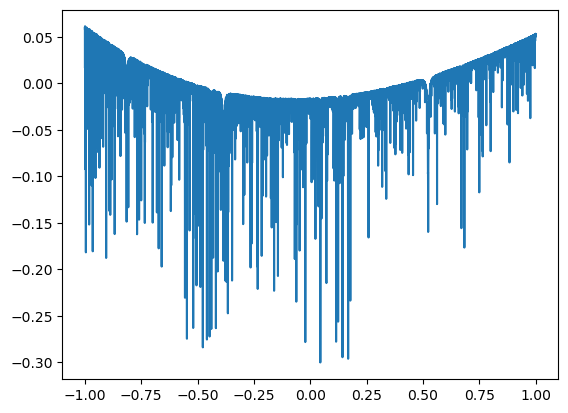

In [23]:
xtest = [model_wave_norm,
         stellar_parameter_normalizers[0].normalize(stellar_parameter_arrs[0][example_idx])*jnp.ones_like(model_wave_norm),
         stellar_parameter_normalizers[1].normalize(stellar_parameter_arrs[1][example_idx])*jnp.ones_like(model_wave_norm),
         stellar_parameter_normalizers[2].normalize(stellar_parameter_arrs[2][example_idx])*jnp.ones_like(model_wave_norm)]
xtest = jnp.stack(xtest, axis=-1)
ytest = ys_split[example_idx]

plt.plot(xtest[...,0], ytest)
xtest.shape, ytest.shape

# Temp-only

Do a simpler training first on just wl and temp

In [24]:
logg_match = xs[..., 2] == stellar_parameter_normalizers[1].normalize(5)
z_match = xs[..., 3] == stellar_parameter_normalizers[2].normalize(0)

temp_only_msk = logg_match & z_match

np.sum(logg_match)/len(logg_match), np.sum(z_match)/len(z_match), np.sum(temp_only_msk)/len(temp_only_msk)

(Array(0.08691626, dtype=float32),
 Array(0.1112581, dtype=float32),
 Array(0.00965736, dtype=float32))

In [ ]:
xss = xs[temp_only_msk, :2]
yss = ys[temp_only_msk]

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

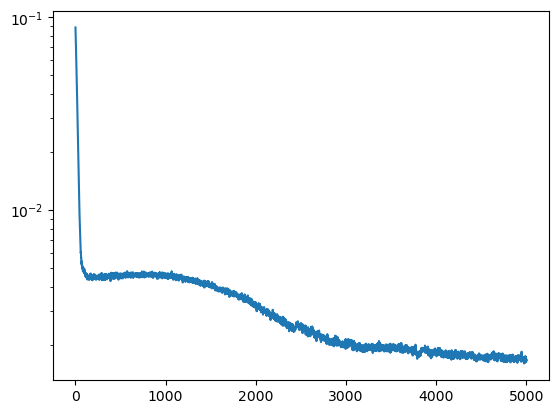

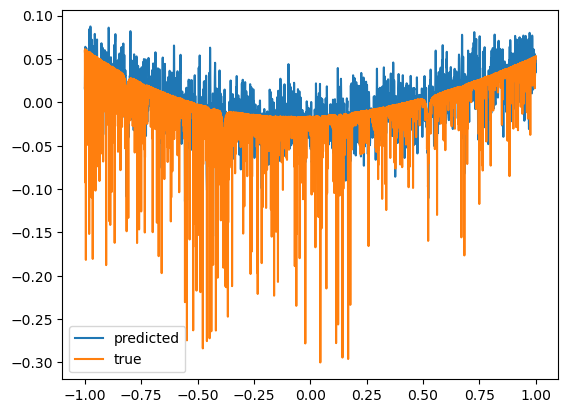

In [52]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=2, rkey=skey, final_activation=jax.nn.tanh)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

# Use skip

Add a linear skip MLP to the model since that might capture the low-frequency elements better.  (Note that the linearization might not be necessary with this but we shall see)

In [27]:
class FDHORes(eqx.Module):
    fdho_layers: list
    last_layers: list
    lin_layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       w0=40, wn0=45, xi0=2**-0.5, phi0=None,
                       num_skip_layers=1,
                       skip_activation=jax.nn.gelu,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers + num_skip_layers + 2)

        layers = [FDHOLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                            w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=True)]
        for i in range(num_hidden_layers):
            layers.append(FDHOLayer(hidden_size, hidden_size, rkey=rkeys[i+1], 
                                    w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=False))
        self.fdho_layers = layers

        layers = []
        layers.append(eqx.nn.Linear(n_in_coo, hidden_size, key=rkeys[-2]))
        layers.append(skip_activation)
        for i in range(num_skip_layers):
            layers.append(eqx.nn.Linear(hidden_size, hidden_size, key=rkeys[-3-i]))
            layers.append(skip_activation)
        self.lin_layers = layers

        self.last_layers = [eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]), jnp.real, final_activation]

    def __call__(self, x):
        xf = x
        for layer in self.fdho_layers:
            xf = layer(xf)

        xl = x
        for layer in self.lin_layers:
            xl = layer(xl)

        # skipish connection
        x = xl + xf

        for layer in self.last_layers:
            x = layer(x)

        return x.squeeze()  

In [28]:
ys_split = models_normed
ys_split.shape

(7559, 8945)

In [29]:
ys = ys_split.ravel()
xs = xs_split.reshape(-1, xs_split.shape[-1])
xs.shape, ys.shape

((67615255, 4), (67615255,))

In [30]:
xss = xs[temp_only_msk, :2]
yss = ys[temp_only_msk]

ytest = ys_split[example_idx]

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(-0.00106925, dtype=float32),
 Array(0.0007196, dtype=float32),
 Array(0.00072075, dtype=float32))

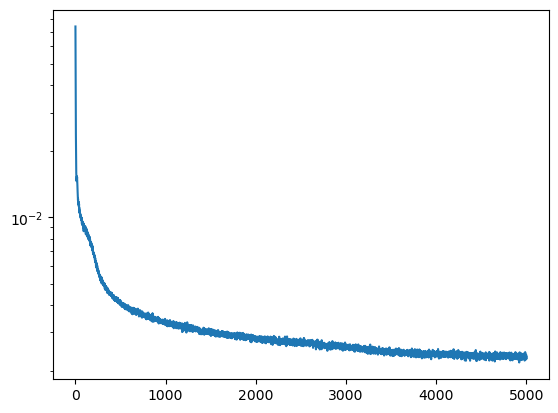

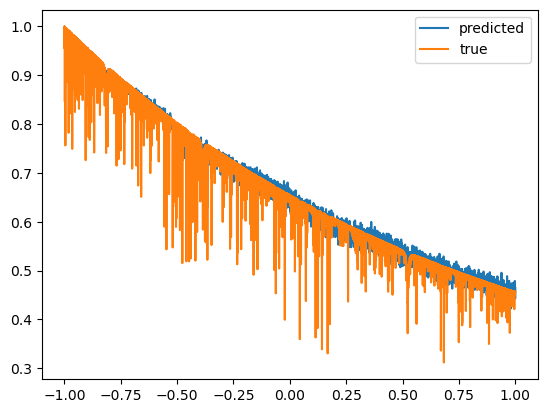

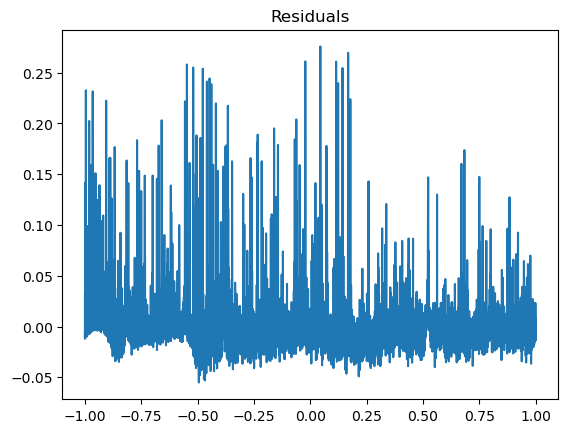

In [31]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

Hyperparameter changes

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(0.00269084, dtype=float32),
 Array(0.00071348, dtype=float32),
 Array(0.00072072, dtype=float32))

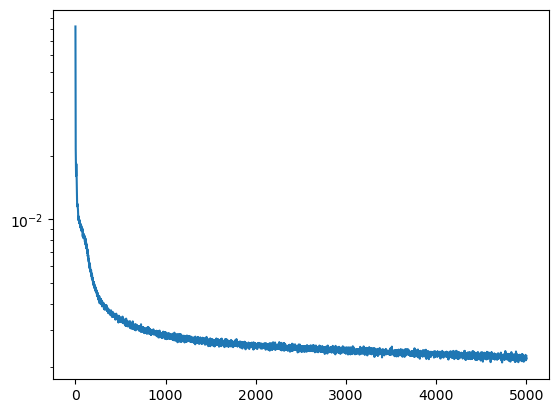

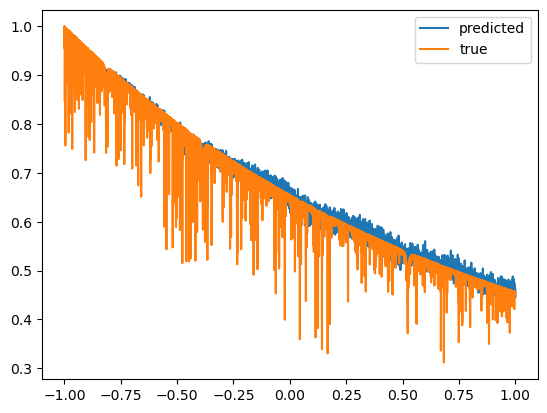

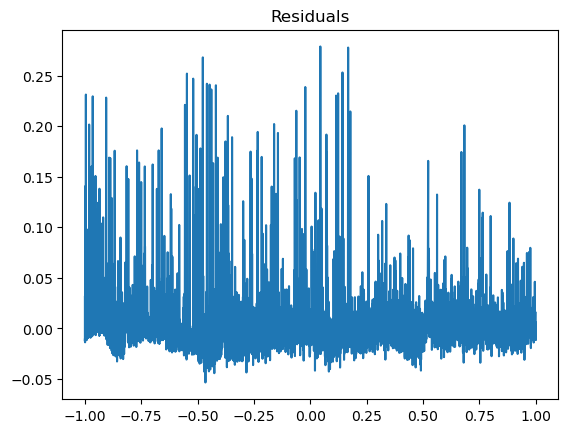

In [33]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  hidden_size=512)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(0.00012672, dtype=float32),
 Array(0.00073082, dtype=float32),
 Array(0.00073084, dtype=float32))

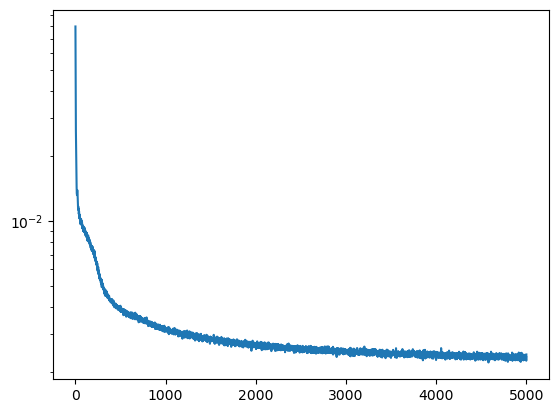

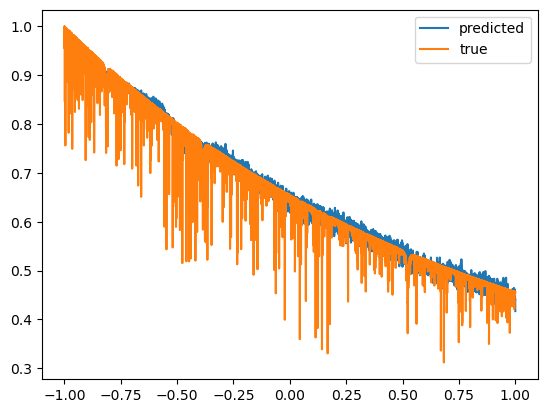

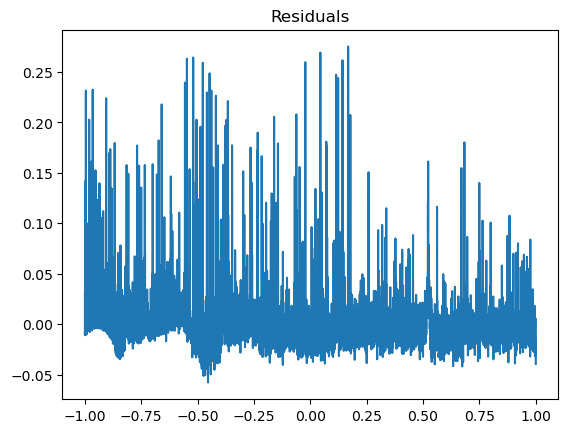

In [34]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  num_hidden_layers=3)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(0.00047793, dtype=float32),
 Array(0.00064472, dtype=float32),
 Array(0.00064494, dtype=float32))

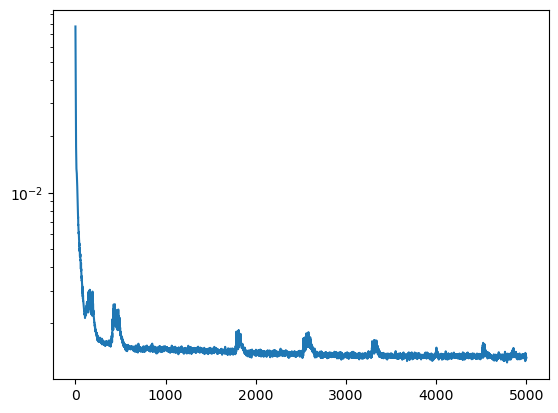

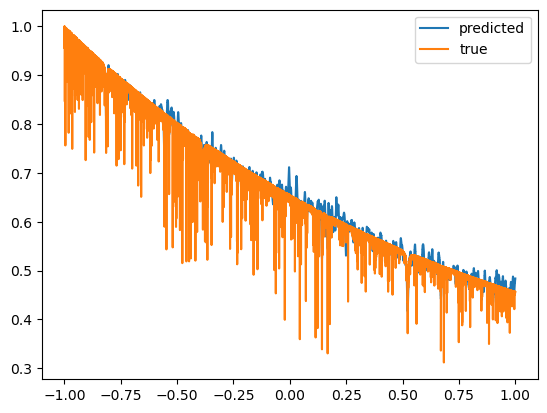

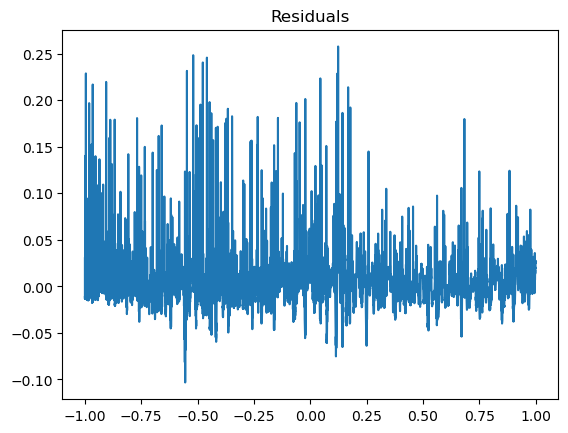

In [35]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  w0=20)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(-7.1980685e-07, dtype=float32),
 Array(0.00068298, dtype=float32),
 Array(0.00068298, dtype=float32))

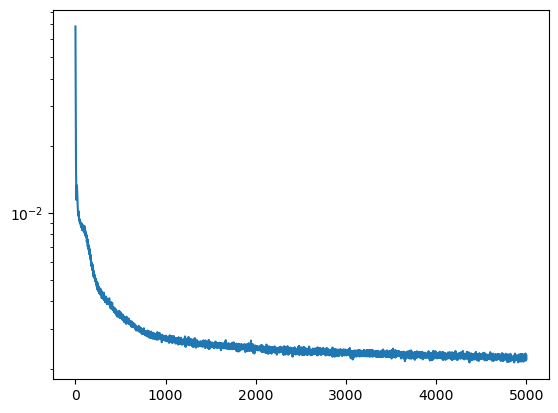

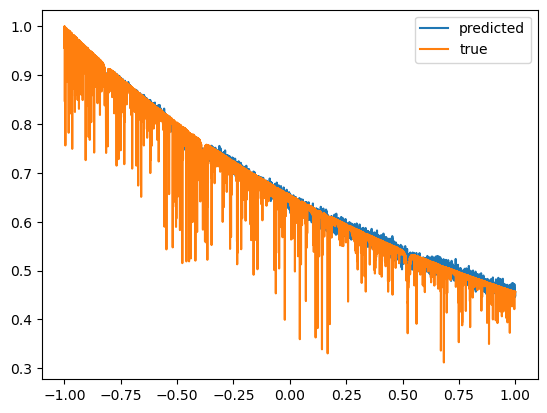

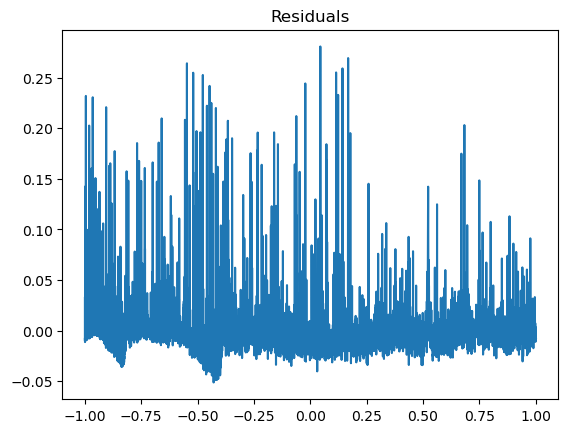

In [36]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  w0=80)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(-0.00116353, dtype=float32),
 Array(0.00054856, dtype=float32),
 Array(0.00054991, dtype=float32))

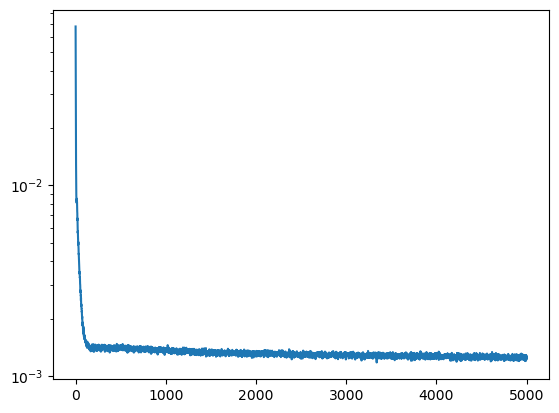

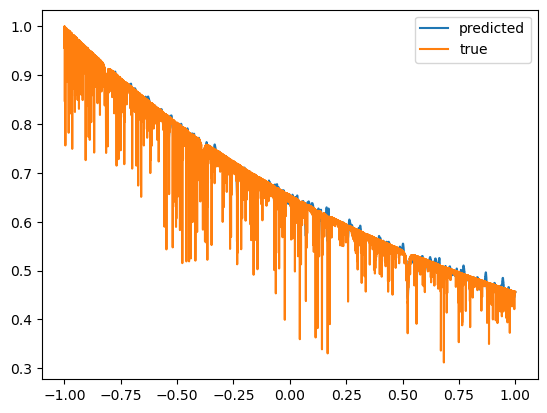

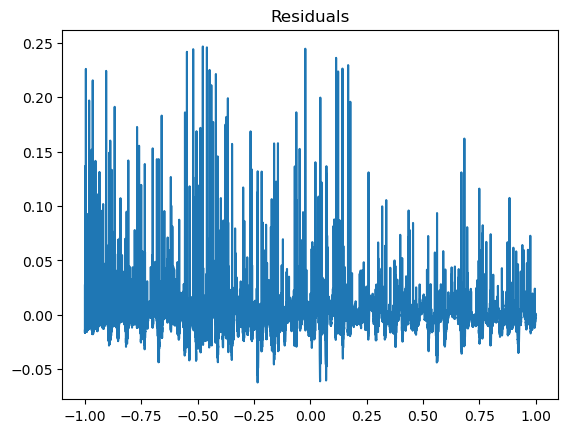

In [38]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  wn0=40/2)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/5000 [00:00<?, ?it/s]

(Array(-2.9702103e-05, dtype=float32),
 Array(0.00073181, dtype=float32),
 Array(0.00073181, dtype=float32))

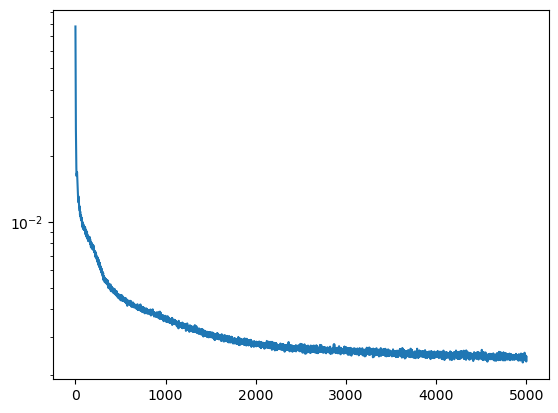

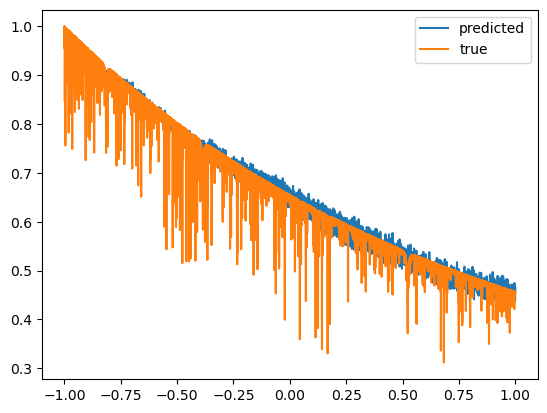

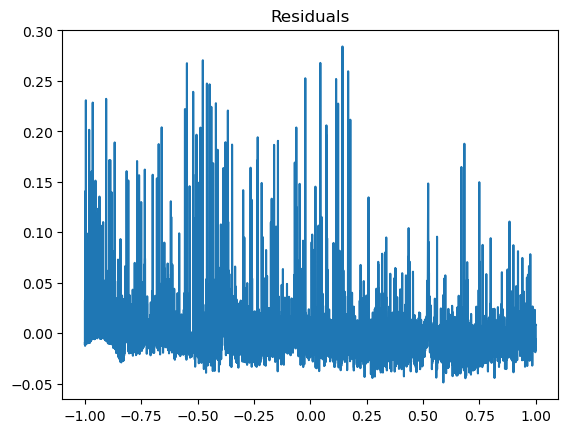

In [37]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid,  wn0=40*2)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

10.0 epochs to sample the entire dataset


  0%|          | 0/10000 [00:00<?, ?it/s]

(Array(0.00070921, dtype=float32),
 Array(0.00061884, dtype=float32),
 Array(0.00061934, dtype=float32))

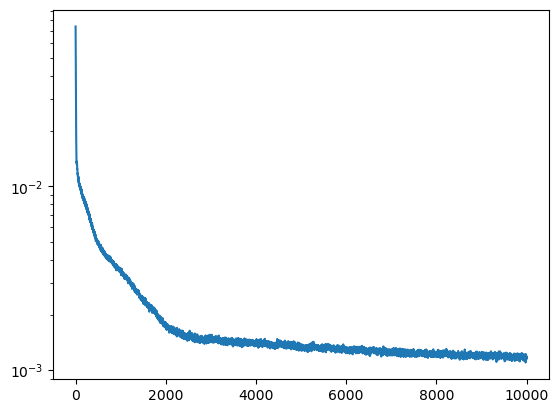

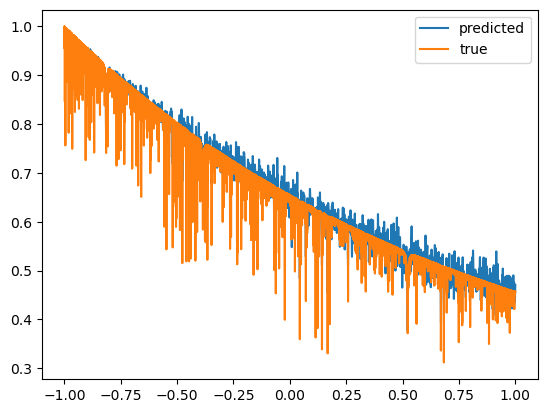

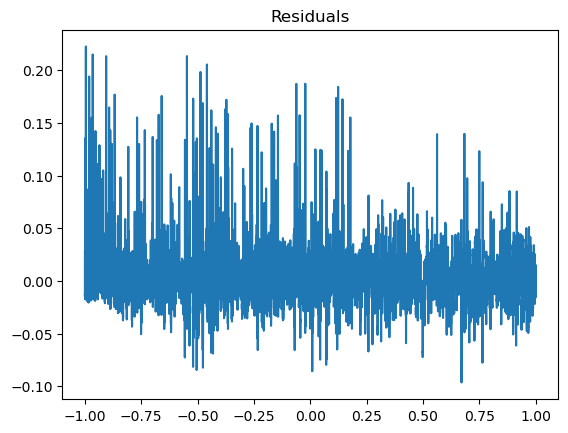

In [39]:
LEARNING_RATE = 5e-4
EPOCHS = 10000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

Might need a more thoughtful learning rate schedule then?

10.0 epochs to sample the entire dataset


  0%|          | 0/10000 [00:00<?, ?it/s]

(Array(0.00095696, dtype=float32),
 Array(0.00067481, dtype=float32),
 Array(0.00067572, dtype=float32))

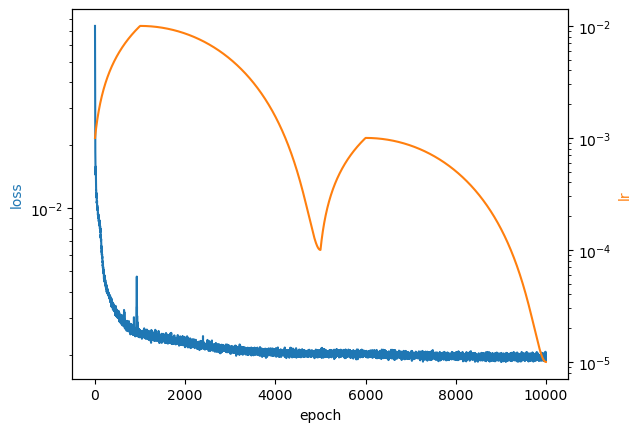

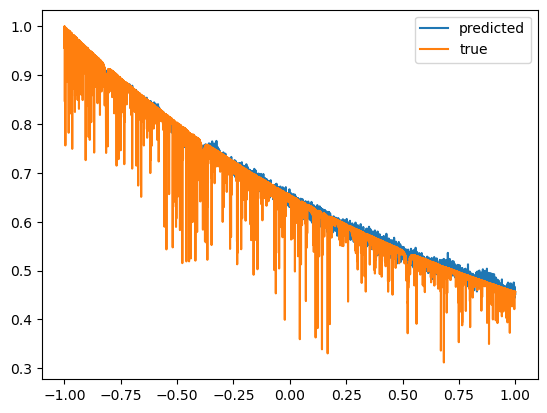

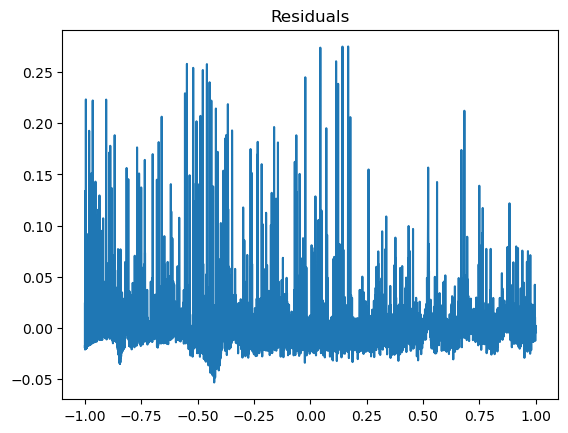

In [68]:
EPOCHS = 10000
BATCH_SIZE = 65536
#def lr_sched_fn(epoch):
#    f = epoch/epochs

lr_sched_fn = optax.schedules.sgdr_schedule([dict(init_value=1e-3, peak_value=1e-2, warmup_steps=1000, decay_steps=5000, end_value=1e-4), 
                                             dict(init_value=1e-4, peak_value=1e-3, warmup_steps=1000, decay_steps=5000, end_value=1e-5), 
                                            ])


print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey, final_activation=jax.nn.sigmoid)
optimizer = optax.adam(learning_rate=lr_sched_fn)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)
plt.xlabel('epoch')
plt.ylabel('loss', color='C0')
epochs = jnp.arange(EPOCHS)
lrs = lr_sched_fn(epochs)
plt.twinx()
plt.semilogy(epochs, lrs, c='C1')
plt.ylabel('lr', color='C1')

plt.figure()
ypredtest = jax.vmap(model)(xtest[:, :2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()


yres = ypredtest - ytest
plt.figure()
plt.plot(model_wave_norm, yres)
plt.title('Residuals')
jnp.mean(yres), jnp.var(yres), jnp.mean(yres**2)

Try training with only temperatures (restrict age/Z)

In [ ]:
logg_msk = stellar_parameter_normalizers[1].denormalize(xs[:, 1])==5
z_msk = stellar_parameter_normalizers[2].denormalize(xs[:, 2])==0
submsk = logg_msk & z_msk

yss = models_normed.ravel()[submsk]
xss = xs_split.reshape(-1, xs_split.shape[-1])[submsk, :2]

np.sum(submsk)/xs.shape[0], yss.shape, xss.shape

In [ ]:
LEARNING_RATE = 1e-4
EPOCHS = 25000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHORes(n_in_coo=2, rkey=skey)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:,:2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()

Skipless version?

In [ ]:
LEARNING_RATE = 1e-4
EPOCHS = 25000
BATCH_SIZE = 65536

print(f"{yss.size/BATCH_SIZE:.1f} epochs to sample the entire dataset")

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=2, rkey=skey)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, yss.size, shape=(BATCH_SIZE,), replace=False)
    xi = xss[batch_idx]
    yi = yss[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure()
ypredtest = jax.vmap(model)(xtest[:,:2])
plt.plot(model_wave_norm, ypredtest, label='predicted')
plt.plot(model_wave_norm, ytest, label='true')
plt.legend()